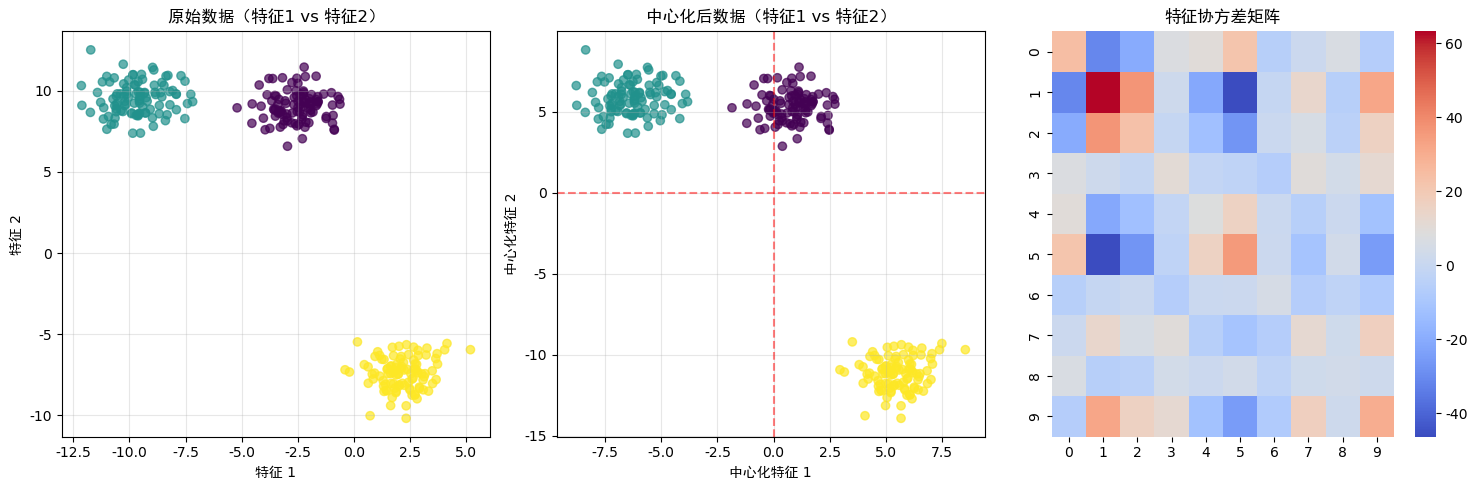

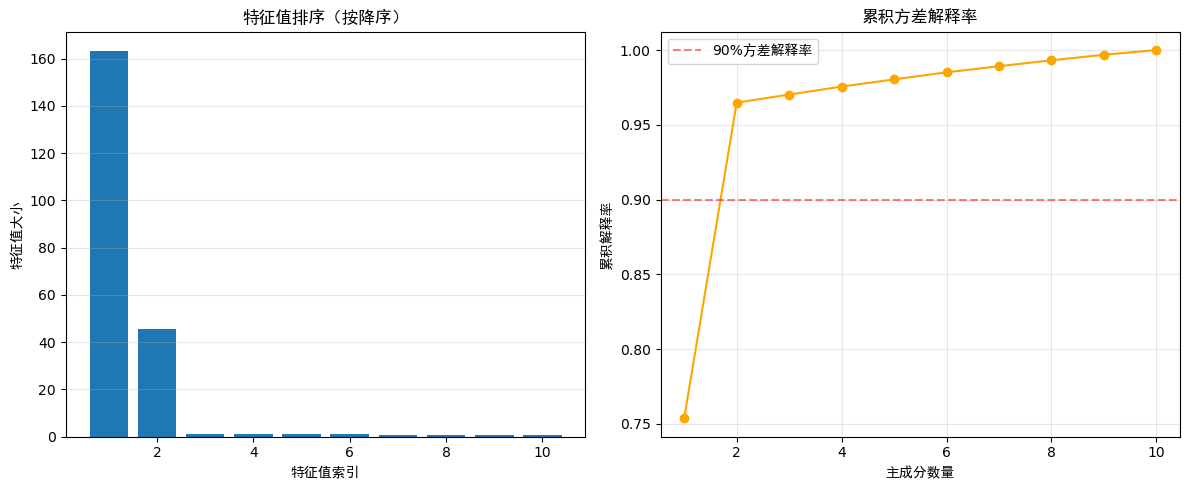

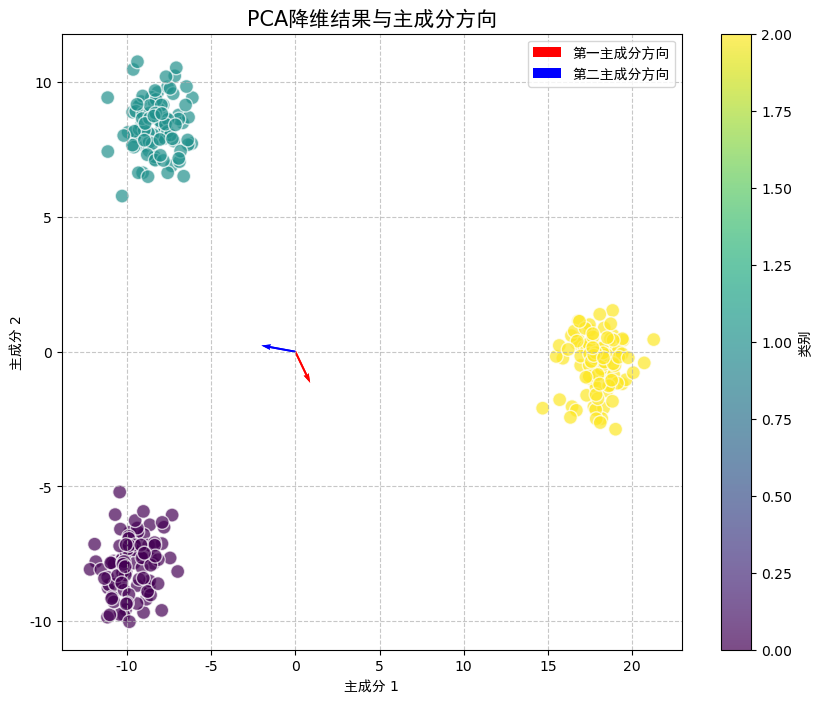

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns  # 用于更美观的热图展示

# 设置随机种子，保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 定义PCA类（与之前相同，此处省略注释）
class PCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.eigenvalues = None  # 新增：保存特征值用于后续分析
        
    def fit(self, X):
        self.mean = torch.mean(X, dim=0)
        X_centered = X - self.mean
        n_samples = X.shape[0]
        covariance_matrix = torch.matmul(X_centered.T, X_centered) / (n_samples - 1)
        
        # 计算特征值和特征向量并保存特征值
        eigenvalues, eigenvectors = torch.linalg.eig(covariance_matrix)
        self.eigenvalues = eigenvalues.real  # 保存特征值
        eigenvectors = eigenvectors.real
        
        sorted_indices = torch.argsort(self.eigenvalues, descending=True)
        top_indices = sorted_indices[:self.n_components]
        self.components = eigenvectors[:, top_indices]

    def transform(self, X):
        X_centered = X - self.mean
        return torch.matmul(X_centered, self.components)
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# 生成测试数据
n_samples = 300
n_features = 10
n_centers = 3
X_np, y_np = make_blobs(n_samples=n_samples, n_features=n_features, 
                       centers=n_centers, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.int64)

# --------------- 新增可视化1：原始数据的两个特征分布 ---------------
plt.figure(figsize=(15, 5))

# 绘制原始数据中两个特征的分布（随机选两个特征）
plt.subplot(131)
feat1, feat2 = 0, 1  # 选择前两个特征
plt.scatter(X[:, feat1], X[:, feat2], c=y, cmap='viridis', alpha=0.7)
plt.title(f'原始数据（特征{feat1+1} vs 特征{feat2+1}）', fontsize=12)
plt.xlabel(f'特征 {feat1+1}')
plt.ylabel(f'特征 {feat2+1}')
plt.grid(alpha=0.3)

# --------------- 新增可视化2：数据中心化前后对比 ---------------
# 计算中心化数据
X_centered = X - X.mean(dim=0)

plt.subplot(132)
plt.scatter(X_centered[:, feat1], X_centered[:, feat2], c=y, cmap='viridis', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)  # x轴零线
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)  # y轴零线
plt.title(f'中心化后数据（特征{feat1+1} vs 特征{feat2+1}）', fontsize=12)
plt.xlabel(f'中心化特征 {feat1+1}')
plt.ylabel(f'中心化特征 {feat2+1}')
plt.grid(alpha=0.3)

# --------------- 新增可视化3：协方差矩阵 ---------------
# 计算协方差矩阵
# 对角线颜色：反映每个特征的方差大小（颜色越深，该特征自身的离散程度越高）。
# 非对角线颜色：反映特征间的相关性（如红色表示强正相关，蓝色表示强负相关）
cov_matrix = torch.matmul(X_centered.T, X_centered) / (X.shape[0] - 1)

plt.subplot(133)
sns.heatmap(cov_matrix.numpy(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('特征协方差矩阵', fontsize=12)
plt.tight_layout()
plt.show()

# 执行PCA降维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# --------------- 新增可视化4：特征值排序与方差解释率 ---------------
plt.figure(figsize=(12, 5))

# 绘制特征值排序
plt.subplot(121)
sorted_eigenvalues = torch.sort(pca.eigenvalues, descending=True)[0]
plt.bar(range(1, len(sorted_eigenvalues)+1), sorted_eigenvalues.numpy())
plt.title('特征值排序（按降序）', fontsize=12)
plt.xlabel('特征值索引')
plt.ylabel('特征值大小')
plt.grid(axis='y', alpha=0.3)

# 绘制方差解释率
plt.subplot(122)
explained_variance_ratio = sorted_eigenvalues / torch.sum(sorted_eigenvalues)
cumulative_ratio = torch.cumsum(explained_variance_ratio, dim=0)
plt.plot(range(1, len(cumulative_ratio)+1), cumulative_ratio.numpy(), 'o-', color='orange')
plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='90%方差解释率')
plt.title('累积方差解释率', fontsize=12)
plt.xlabel('主成分数量')
plt.ylabel('累积解释率')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------- 原有可视化：PCA降维结果 ---------------
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', 
                     alpha=0.7, edgecolors='w', s=100)

# 新增：绘制主成分方向（在中心化数据的前两个特征上投影）
# 缩放主成分向量以便可视化
scale = 5
plt.quiver([0, 0], [0, 0], 
           pca.components[feat1, 0]*scale, pca.components[feat2, 0]*scale, 
           color='red', width=0.003, label='第一主成分方向')
plt.quiver([0, 0], [0, 0], 
           pca.components[feat1, 1]*scale, pca.components[feat2, 1]*scale, 
           color='blue', width=0.003, label='第二主成分方向')

plt.title('PCA降维结果与主成分方向', fontsize=15)
plt.xlabel('主成分 1')
plt.ylabel('主成分 2')
plt.colorbar(scatter, label='类别')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()